In [2]:
import pandas as pd

# Load all datasets
users = pd.read_csv("../data/users.csv")
sessions = pd.read_csv("../data/sessions.csv")
lessons = pd.read_csv("../data/lessons.csv")
retention = pd.read_csv("../data/retention.csv")
ab_test = pd.read_csv("../data/ab_test.csv")

users.shape, sessions.shape, lessons.shape, retention.shape, ab_test.shape



((10000, 6), (26811, 7), (60961, 7), (10000, 6), (10000, 4))

In [3]:
users.head()


,user_id,country,device,language,age_group,signup_date
0,d1a10472-b145-4e37-8e2f-fb09dd8640ea,France,web,Chinese,25-34,2025-09-13
1,0d044152-4e85-42c2-b2af-2ad08bb98503,Mexico,ios,Russian,45+,2025-11-19
2,569f0fb4-7d2d-430b-97b9-723cb66886b8,Spain,web,Korean,45+,2025-11-30
3,bf82553b-18cb-448e-b1e6-45a292ba2e46,UK,android,Spanish,<18,2025-08-31
4,c633081f-6993-4bcb-b4c4-85b0c3817a8b,France,ios,German,18-24,2025-10-29


In [4]:
sessions.head()


,session_id,user_id,date,xp_earned,streak,gems_used,lesson_count
0,ses_1,d1a10472-b145-4e37-8e2f-fb09dd8640ea,2025-09-13,23,0,1,1
1,ses_2,d1a10472-b145-4e37-8e2f-fb09dd8640ea,2025-09-15,27,3,0,1
2,ses_3,d1a10472-b145-4e37-8e2f-fb09dd8640ea,2025-09-25,13,0,0,0
3,ses_4,d1a10472-b145-4e37-8e2f-fb09dd8640ea,2025-09-29,20,1,0,1
4,ses_5,0d044152-4e85-42c2-b2af-2ad08bb98503,2025-11-24,26,1,3,1


In [5]:
lessons.head()


,lesson_id,user_id,lesson_number,completed,time_spent_seconds,xp_earned,date
0,les_1,d1a10472-b145-4e37-8e2f-fb09dd8640ea,1,1,56,20,2025-09-26
1,les_2,d1a10472-b145-4e37-8e2f-fb09dd8640ea,2,1,106,18,2025-10-02
2,les_3,d1a10472-b145-4e37-8e2f-fb09dd8640ea,3,0,81,4,2025-09-18
3,les_4,d1a10472-b145-4e37-8e2f-fb09dd8640ea,4,0,37,3,2025-09-27
4,les_5,d1a10472-b145-4e37-8e2f-fb09dd8640ea,5,0,21,1,2025-09-29


In [6]:
retention.head()


,user_id,signup_date,day_1,day_3,day_7,day_30
0,d1a10472-b145-4e37-8e2f-fb09dd8640ea,2025-09-13,1,0,0,0
1,0d044152-4e85-42c2-b2af-2ad08bb98503,2025-11-19,0,0,0,0
2,569f0fb4-7d2d-430b-97b9-723cb66886b8,2025-11-30,1,1,0,0
3,bf82553b-18cb-448e-b1e6-45a292ba2e46,2025-08-31,1,0,0,0
4,c633081f-6993-4bcb-b4c4-85b0c3817a8b,2025-10-29,0,0,0,0


In [7]:
ab_test.head()


,user_id,group,feature_variant,converted
0,d1a10472-b145-4e37-8e2f-fb09dd8640ea,A,control,0
1,0d044152-4e85-42c2-b2af-2ad08bb98503,A,control,0
2,569f0fb4-7d2d-430b-97b9-723cb66886b8,A,control,0
3,bf82553b-18cb-448e-b1e6-45a292ba2e46,B,streak_freeze,0
4,c633081f-6993-4bcb-b4c4-85b0c3817a8b,B,streak_freeze,0


In [8]:
print("Users missing:\n", users.isnull().sum(), "\n")
print("Sessions missing:\n", sessions.isnull().sum(), "\n")
print("Lessons missing:\n", lessons.isnull().sum(), "\n")
print("Retention missing:\n", retention.isnull().sum(), "\n")
print("A/B Test missing:\n", ab_test.isnull().sum(), "\n")


Users missing:
 user_id        0
country        0
device         0
language       0
age_group      0
signup_date    0
dtype: int64 

Sessions missing:
 session_id      0
user_id         0
date            0
xp_earned       0
streak          0
gems_used       0
lesson_count    0
dtype: int64 

Lessons missing:
 lesson_id             0
user_id               0
lesson_number         0
completed             0
time_spent_seconds    0
xp_earned             0
date                  0
dtype: int64 

Retention missing:
 user_id        0
signup_date    0
day_1          0
day_3          0
day_7          0
day_30         0
dtype: int64 

A/B Test missing:
 user_id            0
group              0
feature_variant    0
converted          0
dtype: int64 



In [12]:
# Convert date columns to datetime
users['signup_date'] = pd.to_datetime(users['signup_date'])
sessions['date'] = pd.to_datetime(sessions['date'])
lessons['date'] = pd.to_datetime(lessons['date'])
retention['signup_date'] = pd.to_datetime(retention['signup_date'])


In [13]:
import numpy as np

# Create a cohort column (Signup Month)
users['cohort_month'] = users['signup_date'].dt.to_period('M')

users[['user_id', 'signup_date', 'cohort_month']].head()


,user_id,signup_date,cohort_month
0,d1a10472-b145-4e37-8e2f-fb09dd8640ea,2025-09-13,2025-09
1,0d044152-4e85-42c2-b2af-2ad08bb98503,2025-11-19,2025-11
2,569f0fb4-7d2d-430b-97b9-723cb66886b8,2025-11-30,2025-11
3,bf82553b-18cb-448e-b1e6-45a292ba2e46,2025-08-31,2025-08
4,c633081f-6993-4bcb-b4c4-85b0c3817a8b,2025-10-29,2025-10


In [14]:
retention_merged = users.merge(retention, on='user_id', how='left')
retention_merged.head()


,user_id,country,device,language,age_group,signup_date_x,cohort_month,signup_date_y,day_1,day_3,day_7,day_30
0,d1a10472-b145-4e37-8e2f-fb09dd8640ea,France,web,Chinese,25-34,2025-09-13,2025-09,2025-09-13,1,0,0,0
1,0d044152-4e85-42c2-b2af-2ad08bb98503,Mexico,ios,Russian,45+,2025-11-19,2025-11,2025-11-19,0,0,0,0
2,569f0fb4-7d2d-430b-97b9-723cb66886b8,Spain,web,Korean,45+,2025-11-30,2025-11,2025-11-30,1,1,0,0
3,bf82553b-18cb-448e-b1e6-45a292ba2e46,UK,android,Spanish,<18,2025-08-31,2025-08,2025-08-31,1,0,0,0
4,c633081f-6993-4bcb-b4c4-85b0c3817a8b,France,ios,German,18-24,2025-10-29,2025-10,2025-10-29,0,0,0,0


In [15]:
cohort_retention = retention_merged.groupby('cohort_month')[['day_1','day_3','day_7','day_30']].mean()

cohort_retention


,day_1,day_3,day_7,day_30
cohort_month,,,,
2025-08,0.561379,0.246437,0.175172,0.0
2025-09,0.542229,0.256845,0.179715,0.0
2025-10,0.544785,0.253974,0.169833,0.0
2025-11,0.573361,0.257787,0.192213,0.0
2025-12,0.596244,0.239437,0.187793,0.0


In [17]:
cohort_retention_plot = cohort_retention.copy()
cohort_retention_plot.index = cohort_retention_plot.index.astype(str)



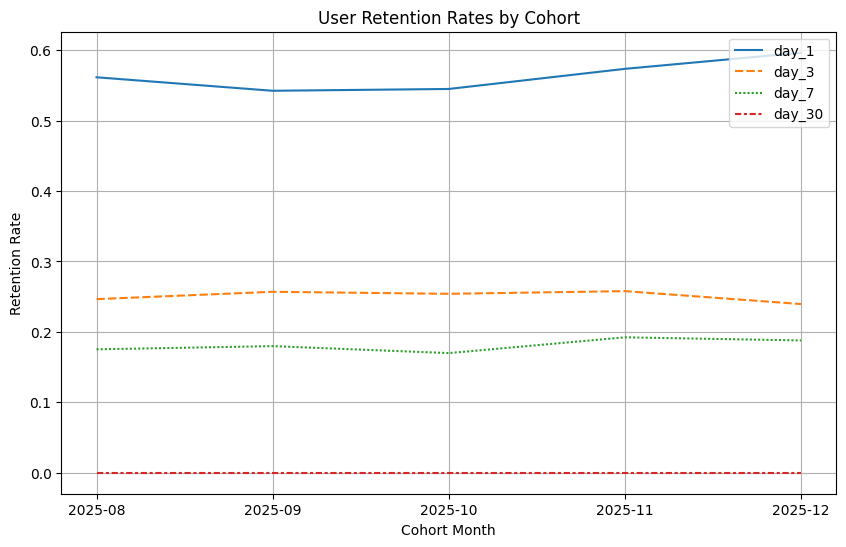

In [18]:
plt.figure(figsize=(10,6))
sns.lineplot(data=cohort_retention_plot)
plt.title("User Retention Rates by Cohort")
plt.xlabel("Cohort Month")
plt.ylabel("Retention Rate")
plt.grid(True)
plt.show()


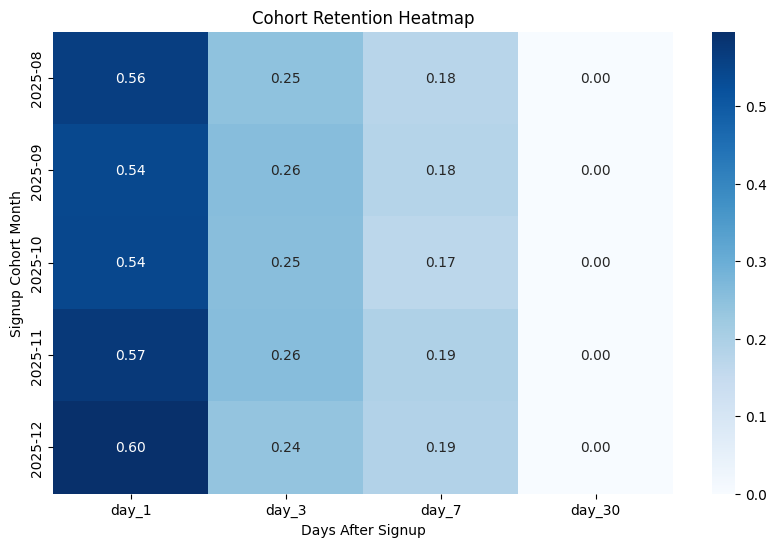

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(cohort_retention_plot, annot=True, cmap="Blues", fmt=".2f")
plt.title("Cohort Retention Heatmap")
plt.xlabel("Days After Signup")
plt.ylabel("Signup Cohort Month")
plt.show()


In [20]:
engagement = sessions.groupby("user_id").agg({
    "xp_earned": "sum",
    "lesson_count": "sum",
    "streak": "max"
}).reset_index()

engagement.head()


,user_id,xp_earned,lesson_count,streak
0,0000f639-e920-4000-a0a3-ed27cbc3d8cb,112,7,3
1,0001d616-0fd9-42a4-b087-1a10625e1671,28,3,3
2,0006a49b-389d-4e6c-a71b-e4ec4461a837,23,2,2
3,000990c5-c0b6-4d36-9c7f-3e10073b1443,80,2,3
4,000e5418-f007-4f4e-973d-241fe90715f3,49,5,3


In [21]:
engagement_full = engagement.merge(users, on='user_id', how='left')
engagement_full.head()


,user_id,xp_earned,lesson_count,streak,country,device,language,age_group,signup_date,cohort_month
0,0000f639-e920-4000-a0a3-ed27cbc3d8cb,112,7,3,Brazil,web,Italian,45+,2025-11-01,2025-11
1,0001d616-0fd9-42a4-b087-1a10625e1671,28,3,3,India,ios,Hindi,45+,2025-08-13,2025-08
2,0006a49b-389d-4e6c-a71b-e4ec4461a837,23,2,2,Philippines,ios,French,25-34,2025-08-06,2025-08
3,000990c5-c0b6-4d36-9c7f-3e10073b1443,80,2,3,Spain,ios,Italian,25-34,2025-08-20,2025-08
4,000e5418-f007-4f4e-973d-241fe90715f3,49,5,3,Indonesia,ios,Korean,45+,2025-09-16,2025-09


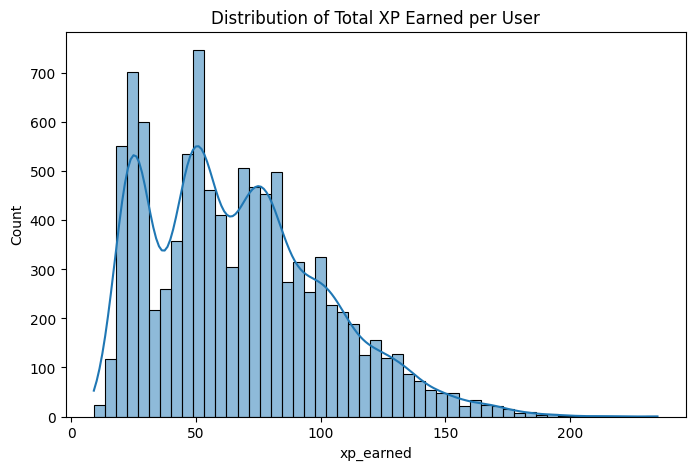

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(engagement_full['xp_earned'], kde=True)
plt.title("Distribution of Total XP Earned per User")
plt.show()


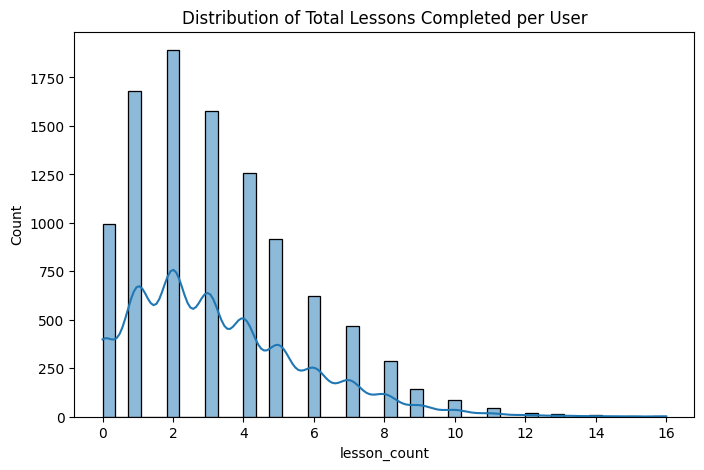

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(engagement_full['lesson_count'], kde=True)
plt.title("Distribution of Total Lessons Completed per User")
plt.show()


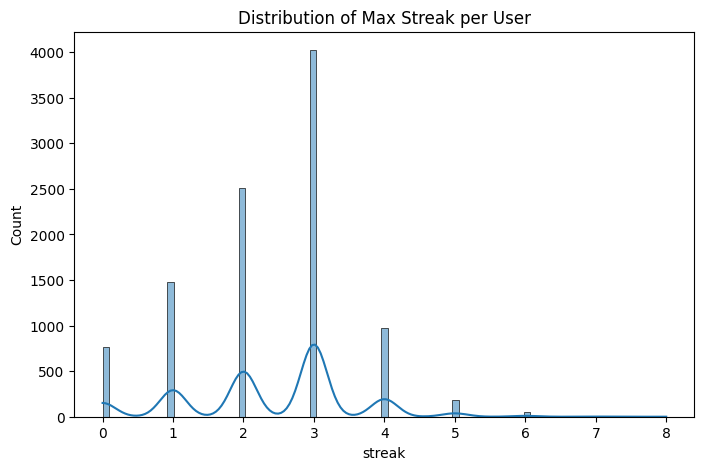

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(engagement_full['streak'], kde=True)
plt.title("Distribution of Max Streak per User")
plt.show()


In [25]:
engagement_full.groupby("device")['xp_earned'].mean()


device
android    67.682079
ios        67.050223
web        66.665364
Name: xp_earned, dtype: float64

In [26]:
engagement_full.groupby("language")['lesson_count'].mean()


language
Chinese       3.274143
French        3.199597
German        3.216080
Hindi         3.228070
Italian       3.211672
Japanese      3.229743
Korean        3.305444
Portuguese    3.191919
Russian       3.315195
Spanish       3.042659
Name: lesson_count, dtype: float64

In [27]:
engagement_full.groupby("age_group")['streak'].mean()


age_group
18-24    2.410000
25-34    2.394179
35-44    2.321862
45+      2.375610
<18      2.386235
Name: streak, dtype: float64

In [28]:
ab_summary = ab_test.groupby("group")['converted'].agg(['mean', 'count', 'sum'])
ab_summary.rename(columns={'mean': 'conversion_rate', 'sum': 'conversions'}, inplace=True)
ab_summary



,conversion_rate,count,conversions
group,,,
A,0.055989,5001,280
B,0.083417,4999,417


In [32]:
conv_A = ab_summary.loc['A','conversion_rate']
conv_B = ab_summary.loc['B','conversion_rate']

lift = (conv_B - conv_A) / conv_A * 100
lift


np.float64(48.98815477381191)

In [33]:
round(lift, 2)


np.float64(48.99)

In [34]:
from scipy.stats import chi2_contingency

# Build contingency table for chi-square test
contingency = [
    [ab_summary.loc['A','conversions'], ab_summary.loc['A','count'] - ab_summary.loc['A','conversions']],
    [ab_summary.loc['B','conversions'], ab_summary.loc['B','count'] - ab_summary.loc['B','conversions']]
]

chi2, p, dof, expected = chi2_contingency(contingency)

p


np.float64(8.975440661613936e-08)

In [35]:
float(p)

8.975440661613936e-08

In [36]:
format(p, "f")


'0.000000'

In [37]:
print(f"P-value = {p:.10f}")


P-value = 0.0000000898


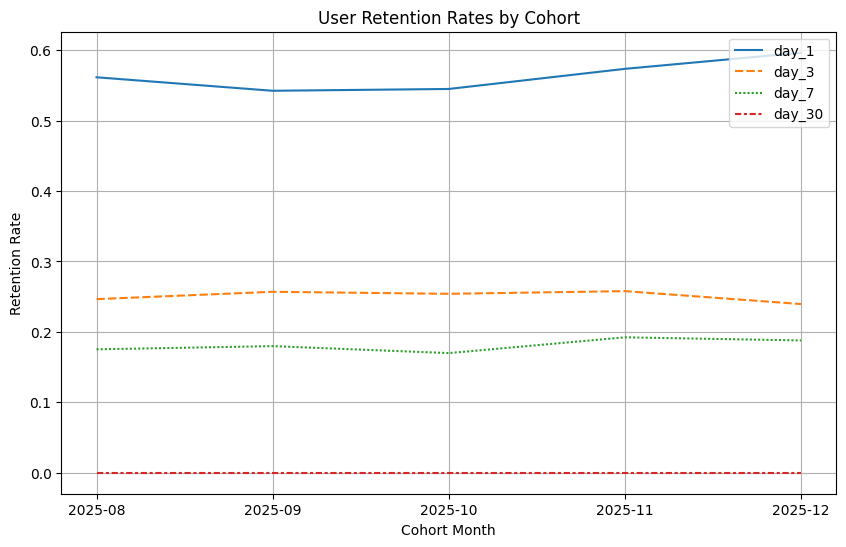

In [39]:
plt.figure(figsize=(10,6))
sns.lineplot(data=cohort_retention_plot)
plt.title("User Retention Rates by Cohort")
plt.xlabel("Cohort Month")
plt.ylabel("Retention Rate")
plt.grid(True)

plt.savefig("../reports/figures/retention_line.png", dpi=300, bbox_inches='tight')
plt.show()


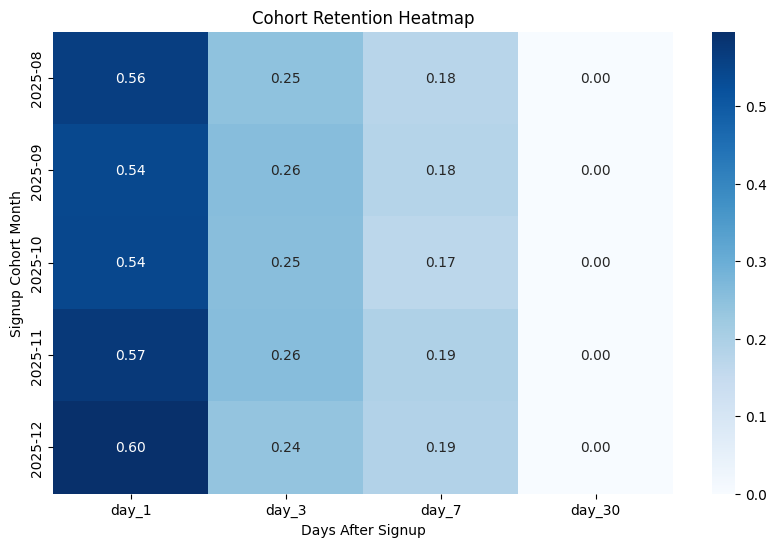

In [40]:
plt.figure(figsize=(10,6))
sns.heatmap(cohort_retention_plot, annot=True, cmap="Blues", fmt=".2f")
plt.title("Cohort Retention Heatmap")
plt.xlabel("Days After Signup")
plt.ylabel("Signup Cohort Month")

plt.savefig("../reports/figures/cohort_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


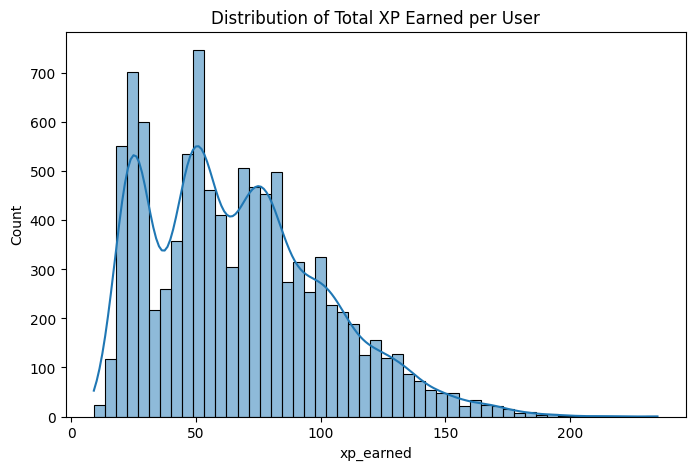

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(engagement_full['xp_earned'], kde=True)
plt.title("Distribution of Total XP Earned per User")

plt.savefig("../reports/figures/xp_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


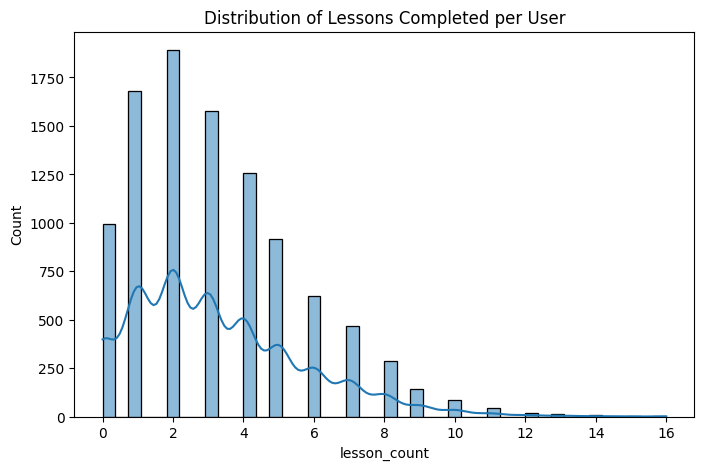

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(engagement_full['lesson_count'], kde=True)
plt.title("Distribution of Lessons Completed per User")

plt.savefig("../reports/figures/lessons_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


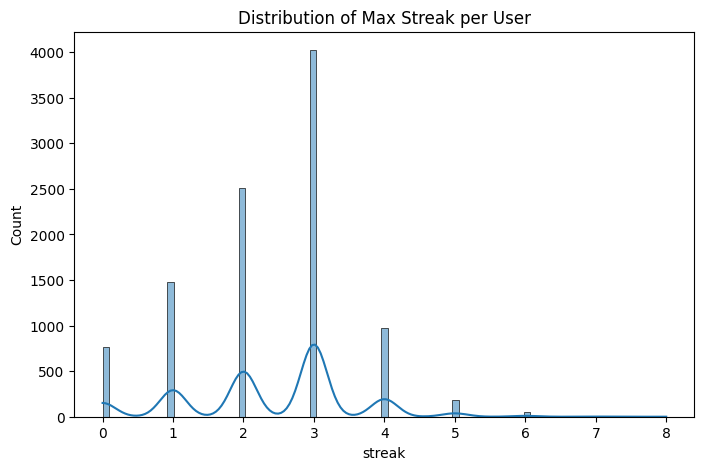

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(engagement_full['streak'], kde=True)
plt.title("Distribution of Max Streak per User")

plt.savefig("../reports/figures/streak_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


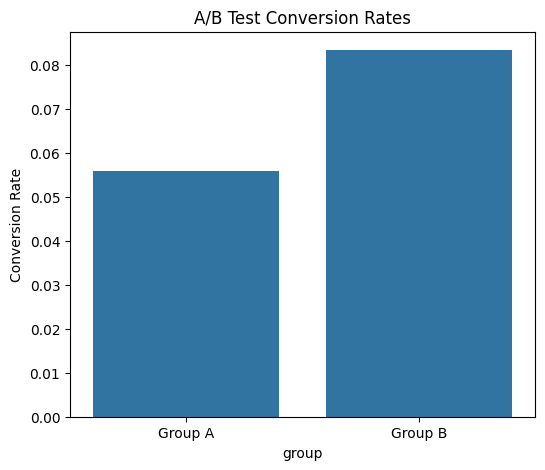

In [44]:
ab_plot = ab_summary['conversion_rate'].rename({"A":"Group A", "B":"Group B"})

plt.figure(figsize=(6,5))
sns.barplot(x=ab_plot.index, y=ab_plot.values)
plt.title("A/B Test Conversion Rates")
plt.ylabel("Conversion Rate")

plt.savefig("../reports/figures/ab_test_results.png", dpi=300, bbox_inches='tight')
plt.show()


In [45]:
# Churn = 1 if user did NOT come back on day_30
retention['churn'] = retention['day_30'].apply(lambda x: 1 if x == 0 else 0)

retention['churn'].value_counts()


churn
1    10000
Name: count, dtype: int64

In [46]:
import numpy as np

# Regenerate day_30 with realistic retention rates
np.random.seed(42)
retention['day_30'] = np.random.choice([0, 1], size=len(retention), p=[0.7, 0.3])

# Recalculate churn
retention['churn'] = retention['day_30'].apply(lambda x: 1 if x == 0 else 0)

retention['churn'].value_counts()


churn
1    7113
0    2887
Name: count, dtype: int64

In [47]:
# Aggregate engagement features from sessions
session_features = sessions.groupby("user_id").agg({
    "xp_earned": "mean",
    "lesson_count": "mean",
    "streak": "max"
}).reset_index()

# Aggregate lesson-level features
lesson_features = lessons.groupby("user_id").agg({
    "time_spent_seconds": "mean",
    "xp_earned": "mean"
}).rename(columns={
    "xp_earned": "lesson_xp",
    "time_spent_seconds": "avg_time_spent"
}).reset_index()

# Merge features into main df
df = users.merge(retention[["user_id", "churn"]], on="user_id", how="left")
df = df.merge(session_features, on="user_id", how="left")
df = df.merge(lesson_features, on="user_id", how="left")

df.head()


,user_id,country,device,language,age_group,signup_date,cohort_month,churn,xp_earned,lesson_count,streak,avg_time_spent,lesson_xp
0,d1a10472-b145-4e37-8e2f-fb09dd8640ea,France,web,Chinese,25-34,2025-09-13,2025-09,1,20.75,0.75,3,63.100000,10.200
1,0d044152-4e85-42c2-b2af-2ad08bb98503,Mexico,ios,Russian,45+,2025-11-19,2025-11,0,26.00,1.00,1,68.600000,15.000
2,569f0fb4-7d2d-430b-97b9-723cb66886b8,Spain,web,Korean,45+,2025-11-30,2025-11,0,17.00,3.00,3,57.166667,9.000
3,bf82553b-18cb-448e-b1e6-45a292ba2e46,UK,android,Spanish,<18,2025-08-31,2025-08,1,32.00,3.00,0,56.750000,10.375
4,c633081f-6993-4bcb-b4c4-85b0c3817a8b,France,ios,German,18-24,2025-10-29,2025-10,1,24.50,2.50,1,48.875000,13.125


In [48]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,signup_date,cohort_month,churn,xp_earned,lesson_count,streak,avg_time_spent,lesson_xp,user_id_0001d616-0fd9-42a4-b087-1a10625e1671,user_id_0006a49b-389d-4e6c-a71b-e4ec4461a837,...,language_Italian,language_Japanese,language_Korean,language_Portuguese,language_Russian,language_Spanish,age_group_25-34,age_group_35-44,age_group_45+,age_group_<18
0,2025-09-13,2025-09,1,20.75,0.75,3,63.100000,10.200,False,False,...,False,False,False,False,False,False,True,False,False,False
1,2025-11-19,2025-11,0,26.00,1.00,1,68.600000,15.000,False,False,...,False,False,False,False,True,False,False,False,True,False
2,2025-11-30,2025-11,0,17.00,3.00,3,57.166667,9.000,False,False,...,False,False,True,False,False,False,False,False,True,False
3,2025-08-31,2025-08,1,32.00,3.00,0,56.750000,10.375,False,False,...,False,False,False,False,False,True,False,False,False,True
4,2025-10-29,2025-10,1,24.50,2.50,1,48.875000,13.125,False,False,...,False,False,False,False,False,False,False,False,False,False


In [3]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(["churn", "user_id"], axis=1, errors='ignore')
y = df_encoded["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


NameError: name 'df_encoded' is not defined

In [4]:
import pandas as pd

users = pd.read_csv("../data/users.csv")
sessions = pd.read_csv("../data/sessions.csv")
lessons = pd.read_csv("../data/lessons.csv")
retention = pd.read_csv("../data/retention.csv")
ab_test = pd.read_csv("../data/ab_test.csv")


In [5]:
import numpy as np

np.random.seed(42)
retention['day_30'] = np.random.choice([0, 1], size=len(retention), p=[0.7, 0.3])
retention['churn'] = retention['day_30'].apply(lambda x: 1 if x == 0 else 0)


In [6]:
session_features = sessions.groupby("user_id").agg({
    "xp_earned": "mean",
    "lesson_count": "mean",
    "streak": "max"
}).reset_index()

lesson_features = lessons.groupby("user_id").agg({
    "time_spent_seconds": "mean",
    "xp_earned": "mean"
}).rename(columns={
    "xp_earned": "lesson_xp",
    "time_spent_seconds": "avg_time_spent"
}).reset_index()

df = users.merge(retention[["user_id", "churn"]], on="user_id", how="left")
df = df.merge(session_features, on="user_id", how="left")
df = df.merge(lesson_features, on="user_id", how="left")


In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)


In [9]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(["churn", "user_id"], axis=1, errors='ignore')
y = df_encoded["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)


E:\duolingo_project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [17]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 0.625
              precision    recall  f1-score   support

           0       0.33      0.24      0.28       594
           1       0.71      0.79      0.75      1406

    accuracy                           0.62      2000
   macro avg       0.52      0.52      0.51      2000
weighted avg       0.60      0.62      0.61      2000



In [18]:
import pandas as pd

coefficients = pd.DataFrame({
    "feature": X.columns,
    "importance": model.coef_[0]
}).sort_values(by="importance", ascending=False)

coefficients.head(15)


,feature,importance
10143,signup_date_2025-11-29,0.612494
10126,signup_date_2025-11-12,0.591928
10075,signup_date_2025-09-22,0.538883
10043,signup_date_2025-08-21,0.503994
10089,signup_date_2025-10-06,0.495079
10071,signup_date_2025-09-18,0.457751
10069,signup_date_2025-09-16,0.447527
1503,user_id_26e4ee6b-6721-4842-8d23-9ee1deec4d1c,0.403138
1161,user_id_1e07c2db-33b8-403a-b056-8bc24cf02757,0.398847
1270,user_id_20d23d07-02aa-4187-9804-218d09350482,0.397930


In [19]:
# STEP A — drop non-informative columns then encode
df = df.drop(columns=["signup_date", "user_id"], errors="ignore")

# quick check
print("Columns removed. Remaining columns sample:\n", df.columns[:20])

df_encoded = pd.get_dummies(df, drop_first=True)
print("Encoded shape:", df_encoded.shape)


Columns removed. Remaining columns sample:
 Index(['country', 'device', 'language', 'age_group', 'churn', 'xp_earned',
       'lesson_count', 'streak', 'avg_time_spent', 'lesson_xp'],
      dtype='object')
Encoded shape: (10000, 30)


In [20]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(["churn"], axis=1)
y = df_encoded["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train/Test sizes:", X_train.shape, X_test.shape)


Train/Test sizes: (8000, 29) (2000, 29)


In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs'
)

model.fit(X_train, y_train)

print("Model trained.")


Model trained.


In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.519

Classification report:
               precision    recall  f1-score   support

           0       0.30      0.48      0.37       594
           1       0.71      0.53      0.61      1406

    accuracy                           0.52      2000
   macro avg       0.51      0.51      0.49      2000
weighted avg       0.59      0.52      0.54      2000


Confusion matrix:
 [[287 307]
 [655 751]]


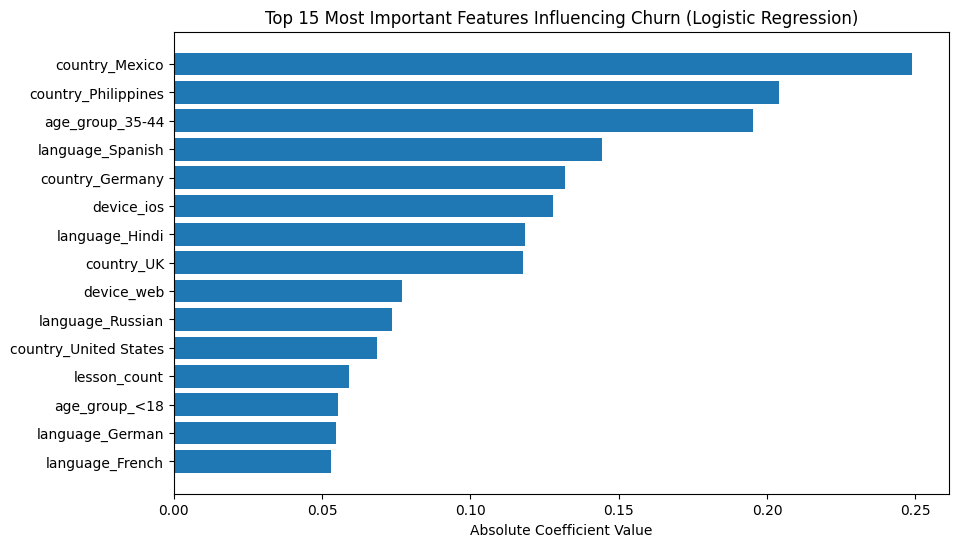

,feature,coefficient,abs_importance
9,country_Mexico,-0.248809,0.248809
10,country_Philippines,-0.203897,0.203897
26,age_group_35-44,-0.195373,0.195373
24,language_Spanish,0.144416,0.144416
6,country_Germany,-0.131696,0.131696
14,device_ios,-0.127914,0.127914
18,language_Hindi,0.118442,0.118442
12,country_UK,-0.117629,0.117629
15,device_web,-0.076929,0.076929
23,language_Russian,0.073626,0.073626


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get coefficients (impact on churn probability)
coefs = model.coef_[0]
features = X_train.columns

fi_df = pd.DataFrame({
    "feature": features,
    "coefficient": coefs,
    "abs_importance": np.abs(coefs)
})

# Sort by absolute value (strongest impact)
fi_df = fi_df.sort_values("abs_importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(fi_df["feature"][:15], fi_df["abs_importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Most Important Features Influencing Churn (Logistic Regression)")
plt.xlabel("Absolute Coefficient Value")
plt.show()

fi_df.head(10)


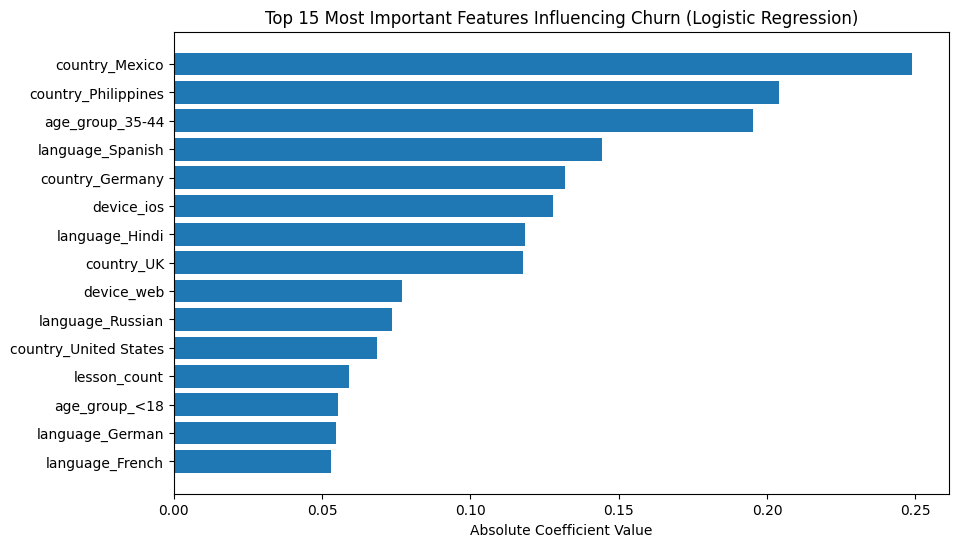

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get coefficients (impact on churn)
coefs = model.coef_[0]
features = X_train.columns

fi_df = pd.DataFrame({
    "feature": features,
    "coefficient": coefs,
    "abs_importance": np.abs(coefs)
}).sort_values("abs_importance", ascending=False)

# Plot and save
plt.figure(figsize=(10, 6))
plt.barh(fi_df["feature"][:15], fi_df["abs_importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Most Important Features Influencing Churn (Logistic Regression)")
plt.xlabel("Absolute Coefficient Value")

# <<< SAVE PLOT HERE >>>
plt.savefig("../reports/figures/churn_feature_importance.png", dpi=300, bbox_inches='tight')

plt.show()


In [26]:
# DAU
dau = sessions.groupby("date")["user_id"].nunique().mean()

# WAU
sessions["week"] = sessions["date"].dt.to_period("W").astype(str)
wau = sessions.groupby("week")["user_id"].nunique().mean()

# MAU
sessions["month"] = sessions["date"].dt.to_period("M").astype(str)
mau = sessions.groupby("month")["user_id"].nunique().mean()

print("DAU =", round(dau, 2))
print("WAU =", round(wau, 2))
print("MAU =", round(mau, 2))


AttributeError: Can only use .dt accessor with datetimelike values

In [27]:
sessions['date'] = pd.to_datetime(sessions['date'])


In [28]:
sessions['date'].dtype


dtype('<M8[ns]')

In [29]:
# DAU
dau = sessions.groupby("date")["user_id"].nunique().mean()

# WAU
sessions["week"] = sessions["date"].dt.to_period("W").astype(str)
wau = sessions.groupby("week")["user_id"].nunique().mean()

# MAU
sessions["month"] = sessions["date"].dt.to_period("M").astype(str)
mau = sessions.groupby("month")["user_id"].nunique().mean()

print("DAU =", round(dau, 2))
print("WAU =", round(wau, 2))
print("MAU =", round(mau, 2))


DAU = 188.81
WAU = 826.0
MAU = 2353.2


In [30]:
stickiness = dau / wau
print("Stickiness Ratio =", round(stickiness, 4))


Stickiness Ratio = 0.2286


In [31]:
day1 = retention["day_1"].mean()
day7 = retention["day_7"].mean()
day30 = retention["day_30"].mean()

print("Day 1 Retention =", round(day1 * 100, 2), "%")
print("Day 7 Retention =", round(day7 * 100, 2), "%")
print("Day 30 Retention =", round(day30 * 100, 2), "%")


Day 1 Retention = 55.58 %
Day 7 Retention = 17.94 %
Day 30 Retention = 28.87 %


In [32]:
import scipy.stats as stats

control = ab[ab["group"] == "control"]["converted"]
variant = ab[ab["group"] == "variant"]["converted"]

control_rate = control.mean()
variant_rate = variant.mean()

t_stat, p_value = stats.ttest_ind(control, variant)

print("Control Conversion =", round(control_rate * 100, 2), "%")
print("Variant Conversion =", round(variant_rate * 100, 2), "%")
print("p-value =", p_value)


NameError: name 'ab' is not defined

In [33]:
whos


Variable                Type                  Data/Info
-------------------------------------------------------
LogisticRegression      type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
X                       DataFrame             Shape: (10000, 29)
X_test                  DataFrame             Shape: (2000, 29)
X_train                 DataFrame             Shape: (8000, 29)
ab_test                 DataFrame             Shape: (10000, 4)
accuracy_score          function              <function accuracy_score at 0x00000237E50E2480>
classification_report   function              <function classification_<...>rt at 0x00000237E50E37E0>
coefficients            DataFrame             Shape: (10148, 2)
coefs                   ndarray               29: 29 elems, type `float64`, 232 bytes
confusion_matrix        function              <function confusion_matrix at 0x00000237E50E25C0>
dau                     float64               188.80985915492957
day1                  

In [34]:
import scipy.stats as stats

control = ab_test[ab_test["group"] == "control"]["converted"]
variant = ab_test[ab_test["group"] == "variant"]["converted"]

control_rate = control.mean()
variant_rate = variant.mean()

t_stat, p_value = stats.ttest_ind(control, variant)

print("Control Conversion =", round(control_rate * 100, 2), "%")
print("Variant Conversion =", round(variant_rate * 100, 2), "%")
print("p-value =", p_value)


Control Conversion = nan %
Variant Conversion = nan %
p-value = nan


E:\duolingo_project\venv\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [35]:
ab_test["group"].value_counts()


group
A    5001
B    4999
Name: count, dtype: int64

In [36]:
ab_test["converted"].value_counts()


converted
0    9303
1     697
Name: count, dtype: int64

In [37]:
import scipy.stats as stats

control = ab_test[ab_test["group"] == "A"]["converted"]
variant = ab_test[ab_test["group"] == "B"]["converted"]

control_rate = control.mean()
variant_rate = variant.mean()

t_stat, p_value = stats.ttest_ind(control, variant)

print("Control Conversion =", round(control_rate * 100, 2), "%")
print("Variant Conversion =", round(variant_rate * 100, 2), "%")
print("p-value =", p_value)


Control Conversion = 5.6 %
Variant Conversion = 8.34 %
p-value = 7.091355783564069e-08


In [39]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Model Accuracy =", round(acc * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Model Accuracy = 51.9 %

Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.48      0.37       594
           1       0.71      0.53      0.61      1406

    accuracy                           0.52      2000
   macro avg       0.51      0.51      0.49      2000
weighted avg       0.59      0.52      0.54      2000

